# [The StatQuest Illustrated Guide to Statistics](https://www.amazon.com/dp/B0GMP7Z9ZL)
## Chapter 09 - Determining How Much Data to Collect with Power Analyses!!!

Copyright 2026, Joshua Starmer

In this notebook we'll learn...

- How sample sizes influences our confidence in the accuracy of an Estimated Mean.
- How to do a Power Analysis for *t*-test.

**NOTE:**
This tutorial assumes that you have installed **[Python](https://www.python.org/)** and read Chapter 9 in **[The StatQuest Illustrated Guide to Statistics](https://www.amazon.com/dp/B0GMP7Z9ZL)**.

----

Since we're using Python, the first thing we do is load in some modules that will help us do math and plot graphs.

In [1]:
import numpy as np # to generate random numbers
from scipy.stats import norm, expon # to generate normal and exponential curves
import seaborn as sns # to draw a graphs and have them look somewhat nice
from statsmodels.stats.power import TTestIndPower ## to do a power analysis for a t-test

# The effects of sample size on our confidence in the accuracy of an Estimated Mean

Here we will take samples from two distributions, the normal distribution and the exponential distribution, and show how the estimated means calculated from those samples tend to get better when the sample size is larger. In other words, our confidence in the accuracy of an estimated mean improves with larger sample size.

We'll start with showing how this works with the normal distribution.

# Normal Distribution

First, let's just draw a normal distribution with mean = 0 and standard deviation = 1.

In [2]:
## create an array of x-axis coordinates
x_axis = np.arange(start=-5, 
                   stop=5.1, 
                   step=0.1)

## print out the first 10 values
x_axis[:10]

array([-5. , -4.9, -4.8, -4.7, -4.6, -4.5, -4.4, -4.3, -4.2, -4.1])

In [3]:
## create an array of y-axis coordinates that correspond to each value in x_axis
## NOTE: 'loc' = location = the mean. This is because the mean is also called
##       a "location parameter" since the mean determines the location of the
##       center, or highest point, of the distribution.

##       'scale' = standard deviation. This is because the standard deviation is
##       also called a "scale parameter". This is because the standard deviation
##       scales the height of the distribution. The larger the standard deviation
##       the smaller the height.
y_axis = norm.pdf(x=x_axis, 
                  loc=0, 
                  scale=1)

## print out the first 10 values
y_axis[:10]

array([1.48671951e-06, 2.43896075e-06, 3.96129909e-06, 6.36982518e-06,
       1.01408521e-05, 1.59837411e-05, 2.49424713e-05, 3.85351967e-05,
       5.89430678e-05, 8.92616572e-05])

<Axes: >

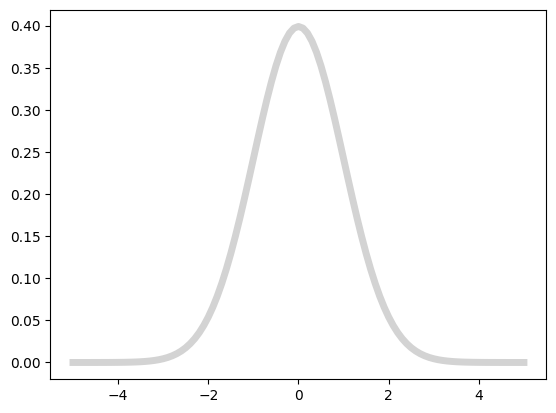

In [4]:
sns.lineplot(x=x_axis, y=y_axis,
            color='lightgrey',
            linewidth=5)

Now let's add the estimated means, calculated with different sample sizes, to the graph. We'll start with *n*=1.

## *n* = 1

First, calculate the means...

In [5]:
## First, make sure our results are reproducable
np.random.seed(5)

num_rand_datasets = 20 # Number of datasets to collect
num_datapoints = 1 # Number of points in each dataset

## means is an array of estimated mean values calculated
## from each dataset.
means = np.empty(num_rand_datasets)

## y_axis is just a bunch of 0s, one per estimated mean
## that we calculate. This is just to put the estimated
## means at the bottom of the graph.
y_axis_means = [0] * num_rand_datasets

## Now create num_rand_datasets datasets
## and calculate an estimated mean with each one
for i in range(num_rand_datasets):
    
    sample = np.random.normal(loc=0, scale=1, size=num_datapoints)
    means[i] = np.mean(sample)

...now add them to our graph of the normal curve.

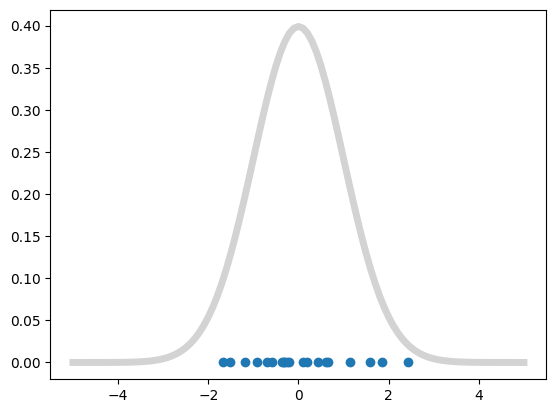

In [6]:
## Now plot the normal distribution that the datasets
## were sampled from...
my_curve = sns.lineplot(x=x_axis, y=y_axis,
                        color='lightgrey',
                        linewidth=5)

## ...and the estimated means.
my_curve.scatter(means, y_axis_means)

Bam! Here we see that when *n*=1, the estimated means are spread out between **-2** and **2.5**. Now let's see what happens when we increase the sample size to *n*=2.

# *n* = 2

**NOTE:** Increasing the sample size to **2** means setting `num.datapoints` to **2**. Everything else is the same as for *n*=1. First, we calculate the means...

In [7]:
np.random.seed(5)

num_rand_datasets = 20
num_datapoints = 2

means = np.empty(num_rand_datasets)
y_axis_means = [0] * num_rand_datasets

for i in range(num_rand_datasets):
    
    sample = np.random.normal(loc=0, scale=1, size=num_datapoints)
    means[i] = np.mean(sample)

...then we add them to the a graph of the normal curve.

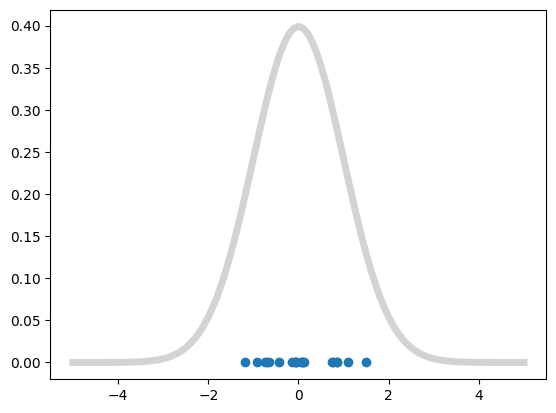

In [8]:
my_curve = sns.lineplot(x=x_axis, y=y_axis,
                        color='lightgrey',
                        linewidth=5)

my_curve.scatter(means, y_axis_means)

Bam! Now, when *n*=2, the estimated means span a range of values from about -1,75 to about 1.75. This is a narrower range of values than before. As a result, we should have more confidence in the accuracy of estimated means when *n*=2 compared to when *n*=1.

Now let's increase the sample size to *n*=5.

## *n* = 5

In [9]:
np.random.seed(5)

num_rand_datasets = 20
num_datapoints = 5

means = np.empty(num_rand_datasets)
y_axis_means = [0] * num_rand_datasets

for i in range(num_rand_datasets):
    
    sample = np.random.normal(loc=0, scale=1, size=num_datapoints)
    means[i] = np.mean(sample)

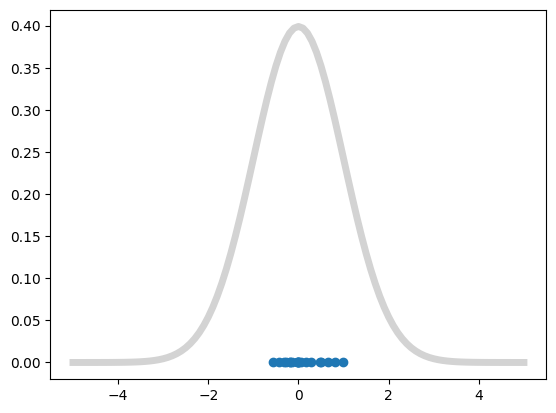

In [10]:
my_curve = sns.lineplot(x=x_axis, y=y_axis,
                        color='lightgrey',
                        linewidth=5)

my_curve.scatter(means, y_axis_means)

Bam! Setting the sample size to *n*=5 resulted in the estimated means forming a tighter cluster around the population mean, 0. Now let's see what happens when we increase the sample size one last time to *n*=10.

## *n* = 10

In [11]:
np.random.seed(5)

num_rand_datasets = 20
num_datapoints = 10

means = np.empty(num_rand_datasets)
y_axis_means = [0] * num_rand_datasets

for i in range(num_rand_datasets):
    
    sample = np.random.normal(loc=0, scale=1, size=num_datapoints)
    means[i] = np.mean(sample)

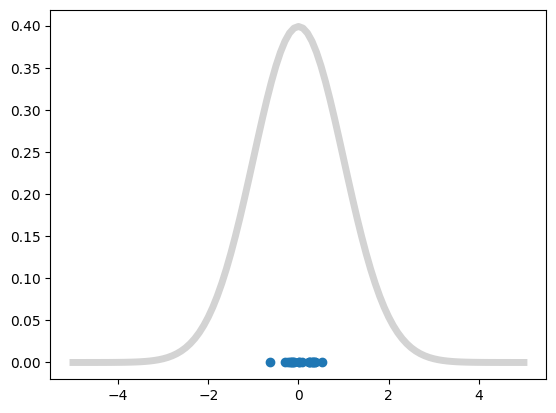

In [12]:
my_curve = sns.lineplot(x=x_axis, y=y_axis,
                        color='lightgrey',
                        linewidth=5)

my_curve.scatter(means, y_axis_means)

Bam! Now we see that each time we increase the sample size, the estimated means cluser closer and closer to the true, population mean. Thus, the larger the sample size, the more confidence we can have that an particular estimated mean is close to the population mean.

Now that we've seen how increasing the sample size results in the estimated mean being closer to the population mean for the **Normal Distribution**, let's see what happens when we use an **Exponential Distribution**.

----

# Exponential Distribution

First, let's just draw an exponential distribution with mean = 2.

**NOTE:** The expoenential distribution function, `expon.pdf()` that comes with `scipy.stats` has one parameter that we need to set called the **mean**. In these examples, we'll set the mean to 2.

**ALSO NOTE:** Since the expoential distribution is not symmetrical, we'll draw a vertical line at the mean value so it is easy to identify. We can do this with the `axvline()` function, which specifically draws vertical lines. To draw a vertical line, you only need to specify the x-axis location for `x`.

In [13]:
## create the x and y-axis coordinates for an
## exponential distribution with mean = 2.
exp_mean = 2

x_axis = np.arange(start=0, 
                   stop=10, 
                   step=0.1)

y_axis = expon.pdf(x_axis, scale=exp_mean)

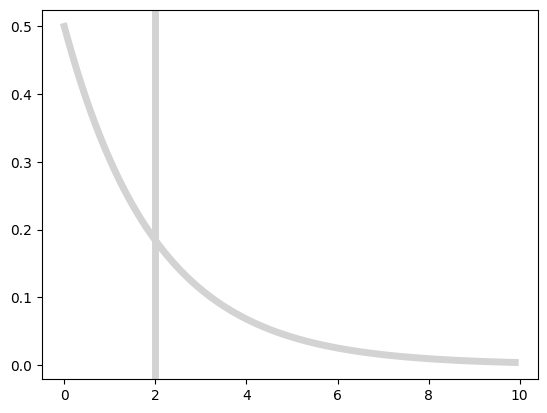

In [14]:
## Now draw the curve and a vertical line at the mean
my_curve = sns.lineplot(x=x_axis, y=y_axis,
                        color='lightgrey',
                        linewidth=5)

## NOTE: Since the expoential distribution is not symmetrical,
## we'll draw a vertical line at the mean value so it is easy
## to identify.
my_curve.axvline(x=exp_mean, 
                 color="lightgrey",
                 linewidth=5)

Bam! Now we know how to draw an exponential distribution and a vertical line at mean value. Now let's see how the estimated means are distributed when the sample size = **1**.

## *n*=1

In [15]:
np.random.seed(5)

num_rand_datasets = 20
num_datapoints = 1

means = np.empty(num_rand_datasets)
y_axis_means = [0] * num_rand_datasets

for i in range(num_rand_datasets):
    
    sample = np.random.exponential(scale=exp_mean, size=num_datapoints)
    means[i] = np.mean(sample)

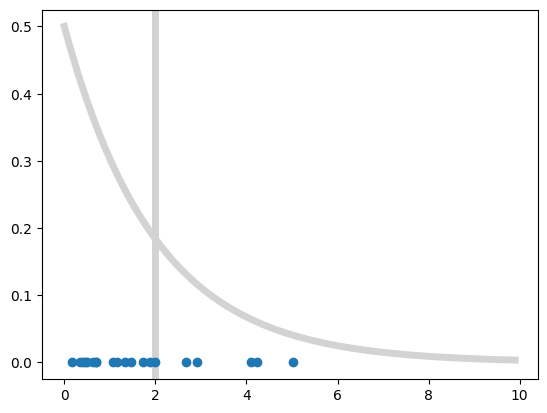

In [16]:
my_curve = sns.lineplot(x=x_axis, y=y_axis,
                        color='lightgrey',
                        linewidth=5)

my_curve.axvline(x=exp_mean, 
                 color="lightgrey",
                 linewidth=5,
                 zorder=0) ## We add "zorder=0" to force python to draw
                           ## the vertical line under everything else

my_curve.scatter(means, 
                 y_axis_means, 
                 zorder=10) ## We add "zorder=10" to force python to draw
                            ## the means on top of everything else.

Now that we can see the range of values estiamted means calculated with *n* = 1 measurements have, let's compare them to estimated means calculated with *n* = 2 measurements.

## *n* = 2

In [17]:
np.random.seed(5)

num_rand_datasets = 20
num_datapoints = 2

means = np.empty(num_rand_datasets)
y_axis_means = [0] * num_rand_datasets

for i in range(num_rand_datasets):
    
    sample = np.random.exponential(scale=exp_mean, size=num_datapoints)
    means[i] = np.mean(sample)

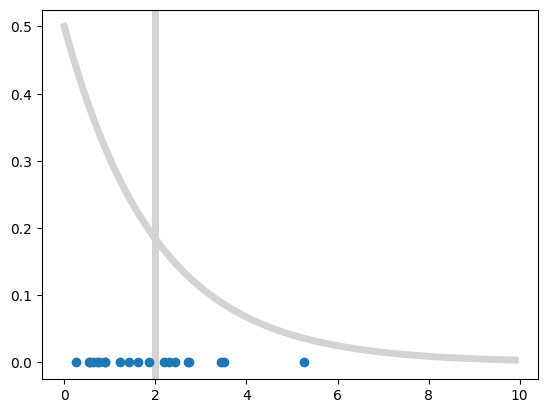

In [18]:
my_curve = sns.lineplot(x=x_axis, y=y_axis,
                        color='lightgrey',
                        linewidth=5)

my_curve.axvline(x=exp_mean, 
                 color="lightgrey",
                 linewidth=5,
                 zorder=0)

my_curve.scatter(means, 
                 y_axis_means, 
                 zorder=10)

...and the results are not exaclty what we were hoping for. When *n* = 2 we see a wider range of values for the esimtated means. However, keep in mind that we're only looking at **20** different estimated means in each case, and it could be (and, in theory, will be) different if we looked at way more estimated means.

We could test that theory by increasing the value for `num.rand.datasets`, but I'll leave that as an exercise for the reader. For now, let's see what happens when we increase the sample size to *n* = 5.

## *n* = 5

In [19]:
np.random.seed(5)

num_rand_datasets = 20
num_datapoints = 5

means = np.empty(num_rand_datasets)
y_axis_means = [0] * num_rand_datasets

for i in range(num_rand_datasets):
    
    sample = np.random.exponential(scale=exp_mean, size=num_datapoints)
    means[i] = np.mean(sample)

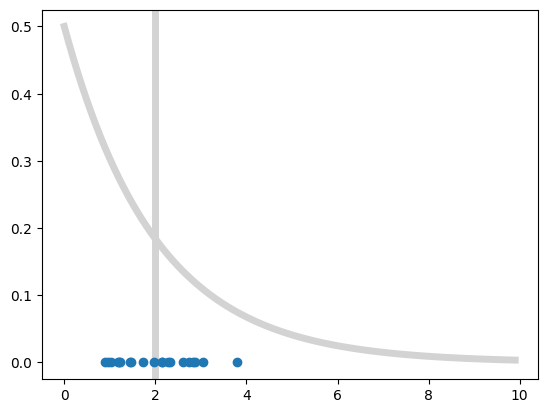

In [20]:
my_curve = sns.lineplot(x=x_axis, y=y_axis,
                        color='lightgrey',
                        linewidth=5)

my_curve.axvline(x=exp_mean, 
                 color="lightgrey",
                 linewidth=5,
                 zorder=0)

my_curve.scatter(means, 
                 y_axis_means, 
                 zorder=10)

Now, with the sampel size set to *n* = 5, we start to see that the means have a slightly smaller range of values compared to when *n* = 1 and when *n* = 2. Now let's increase the sample size to *n* = 10.

## *n* = 10

In [21]:
np.random.seed(5)

num_rand_datasets = 20
num_datapoints = 10

means = np.empty(num_rand_datasets)
y_axis_means = [0] * num_rand_datasets

for i in range(num_rand_datasets):
    
    sample = np.random.exponential(scale=exp_mean, size=num_datapoints)
    means[i] = np.mean(sample)

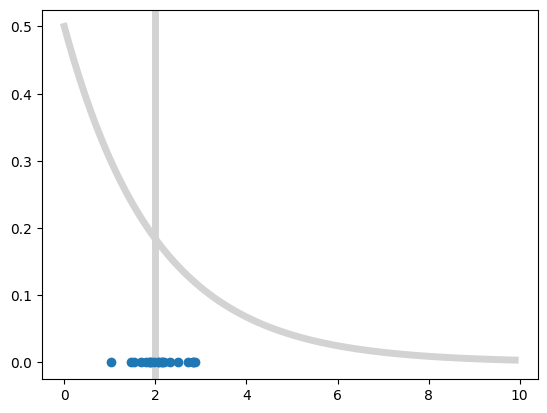

In [22]:
my_curve = sns.lineplot(x=x_axis, y=y_axis,
                        color='lightgrey',
                        linewidth=5)

my_curve.axvline(x=exp_mean, 
                 color="lightgrey",
                 linewidth=5,
                 zorder=0)

my_curve.scatter(means, 
                 y_axis_means, 
                 zorder=10)

And here is where we really see the estimated means cluster more tightly around the population mean, **2**. As a result, when *n*=10, we can have more confidence that any individual estimated mean will be closer to the population mean.

# BAM!

Now let's learn how to do a Power Analysis for a t-test.

----

# How to do a Power Analysis for *t*-test

For pretty much every experiment, it's a good idea to determine if the sample size will be large enough to reject the null hypothesis if the null hypothesis is, indeed, false. In other words, you should always do a **Power Analysis**.

To do a **Power Analysis** for a *t*-test in **Python**, we can use the `TTestIndPower()` and its `solve_power` method.

We'll start using relatively standard parameters values. We'll set probability that we will correctly reject the null hypothesis, if it is indeed false, to 0.8 with `power=0.8`, the threshold for significance to 0.05 with `sig.level=0.05`.

Now, the last two things we need to specify are our estimates of the difference the population means and the standard deviation, using the same value for both populations. For this example, let's assume the difference in the populations means is 1, and we'll assume the standard deviation is also 1. So the effect size is 1/1, and we'll use that to set `effect_size=1/1`.

So, with all those parameters set, we have the following command that we can run:

In [23]:
## create a t-test power analysis object
analysis = TTestIndPower()

## do a power anlysis
analysis.solve_power(effect_size=1/1, power=0.80, alpha=0.05)

16.714722446954013

The output, `16.714722572276173` tells us that we need, exactly **16.71477** obesrvations in each group. Why the this value isn't rounded to the nearest integer is a complete mystery to me. I'm not sure how it would be remotely possible to gather **16.714722572276173** measurements. But, whatever, no one asked me.

Anyway, now let's compare that value to what we get when our estimate of the standard deviation is smaller, **0.5**. This means we'll set `effectsize=1/0.5`.

In [24]:
## do a power anlysis
analysis.solve_power(effect_size=1/0.5, power=0.80, alpha=0.05)

5.0899945682322505

So, when the estimated standard deviation is halfed, the number of measurements requires to get the power we want (80% probability that we will correctly reject the null hypothesis if it is false) drops by over two thirds. Instead of gathering **17** measurements per group, now we just need **5**.

# Double BAM!!

----